# Opium Snippets Topic Modelling

This notebook models topics around opium-related snippets. The reusable modelling logic lives in `code/utils/topic_modelling.py`; this notebook keeps the interpretive workflow visible and organized.

## 1) Setup

In [88]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hdbscan import HDBSCAN
from matplotlib.ticker import StrMethodFormatter
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic.vectorizers import ClassTfidfTransformer

sys.path.append("..")

from utils.constants import KEYWORDS
from utils.topic_modelling import (
    add_keyword_context_flags,
    add_locc_group,
    add_period_column,
    bertopic_size_diagnostics,
    build_stop_words,
    combine_result_frames,
    corpus_frequent_words,
    load_snippets,
    prepare_documents,
    representative_bertopic_documents,
    representative_lda_documents,
    run_bertopic_by_group,
    run_bertopic_model,
    run_lda_by_group,
    run_lda_topic_model,
    save_model_outputs,
    split_snippets_into_sentences,
    top_topics_by_group,
    topic_distribution,
    add_topic_labels,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 180)

In [90]:
DATA_DIR = Path("../../data/snippets")
OUTPUT_DIR = Path("../../data/topic_modelling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SNIPPETS_PARQUET = DATA_DIR / "total_snippets_with_gender.parquet"
SNIPPETS_CSV = DATA_DIR / "total_snippets_with_gender.csv"

RANDOM_STATE = 23
EXPORT_RESULTS = True

HISTORICAL_EMBEDDING_MODEL = "emanjavacas/MacBERTh"
SENTENCE_LEVEL_EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

ALL_LDA_TOPIC_COUNTS = range(2, 20)
GROUP_LDA_TOPIC_COUNTS = range(2, 9)

PERIOD_START_YEAR = 1850
PERIOD_YEARS = 20
N_PERIODS = 4

RUN_SENTENCE_BERTOPIC_TUNING = True
SENTENCE_CONTEXT_WINDOW = 1
SENTENCE_CONTEXT_EMBEDDINGS = OUTPUT_DIR / "sentence_context_embeddings_all_MiniLM_L6_v2.npy"

TUNED_SENTENCE_BERTOPIC_CONFIGS = [
    {"name": "context_leaf_mcs80_ms1_nn12", "min_cluster_size": 80, "min_samples": 1, "n_neighbors": 12},
    {"name": "context_leaf_mcs60_ms1_nn10", "min_cluster_size": 60, "min_samples": 1, "n_neighbors": 10},
    {"name": "context_leaf_mcs40_ms1_nn10", "min_cluster_size": 40, "min_samples": 1, "n_neighbors": 10},
    {"name": "context_leaf_mcs30_ms1_nn8", "min_cluster_size": 30, "min_samples": 1, "n_neighbors": 8},
]

## 2) Loading snippets

In [91]:
df_raw = load_snippets(SNIPPETS_PARQUET, SNIPPETS_CSV)

print(f"Rows: {len(df_raw):,}")
print(f"Books: {df_raw['Book_ID'].nunique():,}")
df_raw.head()

Rows: 5,370
Books: 2,164


,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name
0,0,15,opium,"they would rather not see whales than otherwise. But all in vain; those young Platonists have a notion that their vision is imperfect; they are short-sighted; what use, then, t...",15,"Melville, Herman",PS,1851,male,Male,Whales
1,1,15,paregoric,"questionable; for it is not customary for such venerable leviathans to be at all social. Nevertheless, he stuck to their wake, though indeed their back water must have retarded...",15,"Melville, Herman",PS,1851,male,Male,Stubb
2,2,15,laudanum,"previous when the Pequod spoke the Town-Ho. According to this account and what was subsequently learned, it seemed that the scaramouch in question had gained a wonderful ascend...",15,"Melville, Herman",PS,1851,male,Male,Jeroboam
3,3,44,opium,"and scared you! Nothing to cry about. I’m the same old goods, only a little dented. Sit down on my coat there, and keep me company. I’ve got to lay still a bit.” Dr. Archie and...",44,"Cather, Willa",PS,1915,female,Female,Kronborg
4,4,95,narcotic,"that?” he asked. “Why this,” I answered. “That I shall ill requite the very great honours Ruritania has done me if I depart from it leaving one of those Six alive--neither with...",95,"Hope, Anthony",PR,1894,male,Male,Rupert Hentzau


In [92]:
display(df_raw["Keyword"].value_counts().head(20))

Keyword
opium             2609
morphine           564
narcotic           540
laudanum           503
anodyne            503
nepenthe           274
soporific          248
paregoric           82
heroin              30
codein              10
chandu               6
dover’s powder       1
Name: count, dtype: int64

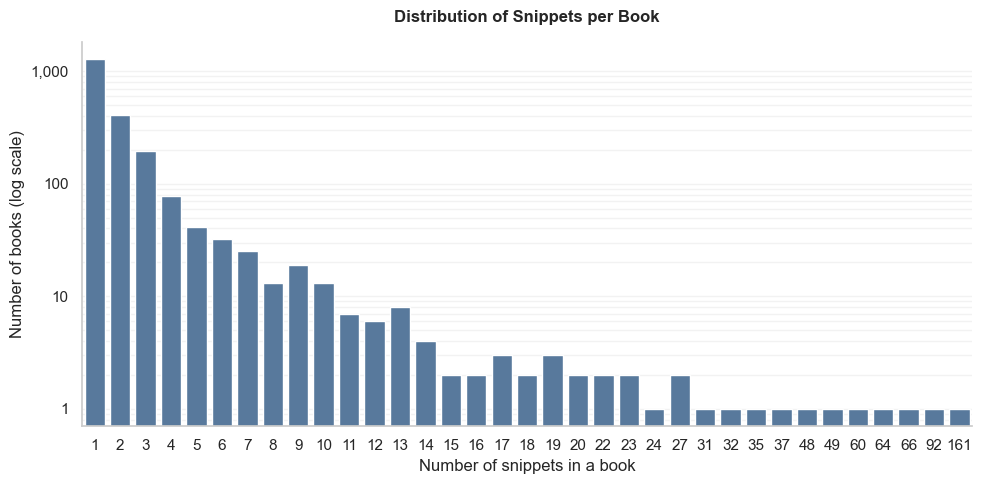

In [93]:
snippets_per_book = df_raw.groupby("Book_ID").size().rename("snippet_counts")
dist = snippets_per_book.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=dist.index, y=dist.values, color="#4C78A8", ax=ax)
ax.set_yscale("log")
ax.set_title("Distribution of Snippets per Book", pad=14, weight="bold")
ax.set_xlabel("Number of snippets in a book")
ax.set_ylabel("Number of books (log scale)")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", which="both", alpha=0.25)
ax.grid(axis="x", visible=False)
sns.despine()
plt.tight_layout()

In [94]:
N = 10
opium_heavy_count = len(snippets_per_book[snippets_per_book > N])
opium_heavy_prop = 100 *  opium_heavy_count / len(snippets_per_book)
print(f"We observe {opium_heavy_count} opium heavy books (more than {N} snippets), ie {opium_heavy_prop:.1f} % of all opium mentionning books.")

df_raw.merge(right=snippets_per_book[snippets_per_book > N], on="Book_ID", how="inner").sort_values(["snippet_counts", "Book_ID"], ascending=False)

We observe 57 opium heavy books (more than 10 snippets), ie 2.6 % of all opium mentionning books.


,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name,snippet_counts
383,1186,4508,nepenthe,"on the comical but for the fact that blank despair was written on the face of the mother. She evidently thought her last day had come, and still, in the convulsions of her pain...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
384,1189,4508,nepenthe,"Nepenthe, which he understood to be rather a small place. A few words of civility over the table d'hote had led to an exchange of cards--a continental custom which Mr. Heard al...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
385,1190,4508,nepenthe,"and more recently in Africa, where women are treated as the veriest beasts. He kept his ideals bright. He would tolerate no flippant allusions to the sex. Muhlen's talk had lef...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
386,1191,4508,nepenthe,"fond of joking. Well, he would humour him. ""You will see our bishop to-morrow,"" he pursued blandly. ""He comes over for the feast of the patron saint; you are lucky in witnessin...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
387,1192,4508,nepenthe,"this your first visit to Nepenthe?"" ""It is. I have heard much about the beauty of the place."" ""You will like it. The people are intelligent. There is good food and wine. Our lo...",4508,"Douglas, Norman",PR,1925,NaN,Unknown (Proper Noun),Anonymous,161
...,...,...,...,...,...,...,...,...,...,...,...,...
114,257,464,opium,The first roads were made under his auspices and by his persuasion. The old road between Hatiheu and Anaho was got under way from either side on the ground that it would be ple...,464,"Stevenson, Robert Louis",PR,1888,male,Unknown,Anonymous,11
115,258,464,opium,"a pillar: the armoury of these drowsy musketeers. At the far end, a little closed house of wood displayed some tinsel curtains, and proved, upon examination, to be a privy on t...",464,"Stevenson, Robert Louis",PR,1888,male,Male,Anonymous,11
116,259,464,opium,"he had earned it well. Again and again, at the command of Nakaeia, he had surrounded houses in the dead of night, cut down the mosquito bars and butchered families. Here was th...",464,"Stevenson, Robert Louis",PR,1888,male,Male,Corpse,11
117,260,464,opium,extreme consistency. Mr. Corpse was afraid of his brother: King Tebureimoa is afraid of the Old Men. Terror of the first nerved him for deeds of desperation; fear of the second...,464,"Stevenson, Robert Louis",PR,1888,male,Male,Kaeia,11


In [95]:
# We manually inspect opium heavy books to exclude false positive, which might heavily skew Topic Modelling
false_opium_heavy_books = [4508, # fictional island called nepenthe
                           42299, # character named ANODYNE + published date = 1822
                           ]
df_raw = df_raw[~df_raw["Book_ID"].isin(false_opium_heavy_books)]

In [96]:
df_docs = prepare_documents(df_raw, text_col="Snippet")
df_docs = add_locc_group(df_docs, locc_col="LoCC")
df_docs = add_period_column(
    df_docs,
    year_col="Published Year",
    start_year=PERIOD_START_YEAR,
    period_years=PERIOD_YEARS,
    n_periods=N_PERIODS,
)

keyword_terms = set(df_docs["Keyword"].dropna().astype(str).str.lower()) | set(KEYWORDS)
STOP_WORDS = build_stop_words(df_docs["Snippet"], keywords=keyword_terms)

print(f"Prepared documents: {len(df_docs):,}")
print(f"Stop words: {len(STOP_WORDS):,}")
df_docs[["snippet_id", "Book_ID", "Keyword", "Assigned_Gender", "LoCC_group", "Period", "document"]].head()

Prepared documents: 5,195
Stop words: 371


,snippet_id,Book_ID,Keyword,Assigned_Gender,LoCC_group,Period,document
0,0,15,opium,Male,American Literature,1850-1869,they would rather not see whales than otherwise but all in vain those young platonists have a notion that their vision is imperfect they are short sighted what use then to stra...
1,1,15,paregoric,Male,American Literature,1850-1869,questionable for it is not customary for such venerable leviathans to be at all social nevertheless he stuck to their wake though indeed their back water must have retarded him...
2,2,15,laudanum,Male,American Literature,1850-1869,previous when the pequod spoke the town ho according to this account and what was subsequently learned it seemed that the scaramouch in question had gained a wonderful ascenden...
3,3,44,opium,Female,American Literature,1910-1929,and scared you nothing to cry about i m the same old goods only a little dented sit down on my coat there and keep me company i ve got to lay still a bit dr archie and mr kronb...
4,4,95,narcotic,Male,English Literature,1890-1909,that he asked why this i answered that i shall ill requite the very great honours ruritania has done me if i depart from it leaving one of those six alive neither with the help...


In [97]:
common_words = corpus_frequent_words(df_docs["Snippet"], min_document_share=0.25)
common_words.head(40)

Snippet
s         6854
opium     3526
said      3072
t         2673
man       2212
like      1960
time      1655
little    1649
did       1636
life      1388
know      1376
mr        1353
Name: count, dtype: int64

## 3) Topic modelling on all snippets

### A) Taking entire snippet

#### a) LDA with document = whole snippet

In [98]:
# ~ 4 min
lda_all = run_lda_topic_model(
    df_docs,
    stop_words=STOP_WORDS,
    candidate_topic_counts=ALL_LDA_TOPIC_COUNTS,
    group_label="all snippets",
    random_state=RANDOM_STATE,
    n_jobs=6,
    min_docs=20,
)

lda_all["scores"]

,n_topics,perplexity,log_likelihood
0,2,5624.950635,-3.283274e+06
1,3,5633.567820,-3.283856e+06
2,4,5641.270843,-3.284375e+06
3,5,5802.105631,-3.295064e+06
4,6,5813.580077,-3.295815e+06
5,7,6001.337921,-3.307901e+06
6,8,6116.975081,-3.315158e+06
7,9,6199.806635,-3.320272e+06
8,10,6243.847062,-3.322964e+06
9,11,6308.862099,-3.326902e+06


Selected topic count: 2


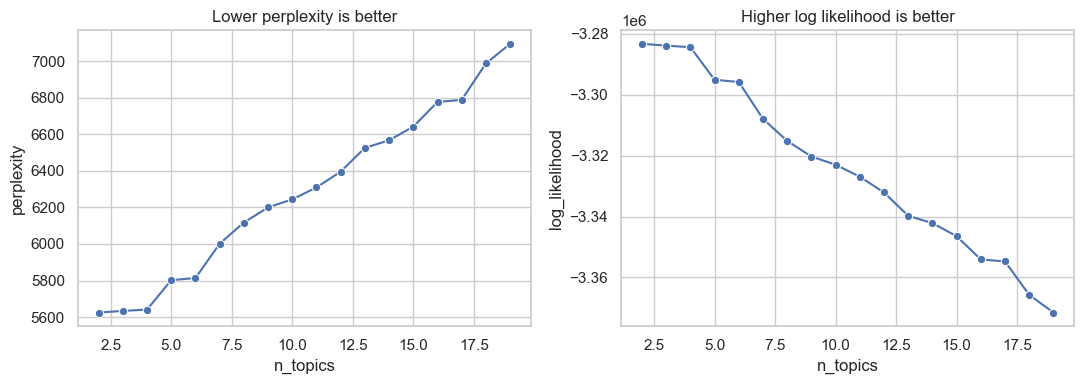

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=lda_all["scores"], x="n_topics", y="perplexity", marker="o", ax=axes[0])
axes[0].set_title("Lower perplexity is better")
sns.lineplot(data=lda_all["scores"], x="n_topics", y="log_likelihood", marker="o", ax=axes[1])
axes[1].set_title("Higher log likelihood is better")
plt.tight_layout()

print(f"Selected topic count: {lda_all['selected_n_topics']}")

In [100]:
lda_all["summary"]

,model_group,dominant_topic,n_documents,mean_weight,n_books,top_terms
0,all snippets,0,3524,0.847760,1719,"night, eyes, room, old, face, day, long, good, hand, away, head, sleep"
1,all snippets,1,1671,0.799129,757,"great, case, death, mind, coleridge, day, years, drug, work, world, good, new"


In [101]:
representative_lda_documents(lda_all["assignments"], topic_id=0, n=8)

,model_group,snippet_id,Book_ID,Keyword,topic_0,Snippet
3180,all snippets,3341,34813,opium,0.994517,"the yellow face reappeared. This time the door opened sufficiently for Trent to see a house-boy in a slop-shop suit and a black skull-cap. ""His Excellency sends greetings and b..."
427,all snippets,427,1182,opium,0.994414,"ancient Sam Tûk and at intervals of five minutes or more he would slowly nod his hairless head. The sliding door which concealed the inner room was partly open, and from the op..."
4745,all snippets,4920,65382,soporific,0.994264,meal at leisure. Donald’s happy laugh rang throughout the sylvan glade and was re-echoed mockingly from the cliffs. The camp-robbers emerged from their retreat looking rather c...
5180,all snippets,5355,73316,opium,0.994258,"axe and pistol in hand, had tumbled a half-dozen stalwart officers,--after them, Yee Wing. There were shrill, warning cries from the street. Shriller cries--the cries of panic-..."
4647,all snippets,4822,62347,opium,0.994255,"Japs, Malays, Lascars, with one or two white girls; and sleek, noiseless attendants swam from couch to couch. Away in the far corner sprawled a lank figure in brown shirting, i..."
4275,all snippets,4450,53289,opium,0.994163,"moment, then lifted it, not looking at him, and turned slowly back into her room. It was dark when he arrived in New York. The flaring streets of the city seemed horrible to hi..."
2247,all snippets,2408,17959,opium,0.994066,"She laughed softly, wickedly, and puffed cigarette smoke into my face. Thrusting her dagger into her waist-belt, and snatching up the brass tray, she swayed down the room, chan..."
2455,all snippets,2616,20429,opium,0.994023,"and Saul strode across a narrow yard, stooping to brush beneath the stout clothes-line hung with blankets, an innocent appearing wash, which however served as an effective barr..."


In [102]:
if EXPORT_RESULTS:
    save_model_outputs(
        OUTPUT_DIR,
        "all_snippets_lda",
        topics=lda_all["topics"],
        summary=lda_all["summary"],
        assignments=lda_all["assignments"],
        scores=lda_all["scores"],
    )

In [103]:
df_docs["Snippet"]

0       they would rather not see whales than otherwise. But all in vain; those young Platonists have a notion that their vision is imperfect; they are short-sighted; what use, then, t...
1       questionable; for it is not customary for such venerable leviathans to be at all social. Nevertheless, he stuck to their wake, though indeed their back water must have retarded...
2       previous when the Pequod spoke the Town-Ho. According to this account and what was subsequently learned, it seemed that the scaramouch in question had gained a wonderful ascend...
3       and scared you! Nothing to cry about. I’m the same old goods, only a little dented. Sit down on my coat there, and keep me company. I’ve got to lay still a bit.” Dr. Archie and...
4       that?” he asked. “Why this,” I answered. “That I shall ill requite the very great honours Ruritania has done me if I depart from it leaving one of those Six alive--neither with...
                                                            

In [104]:
df_docs[df_docs.drop(columns="Authors").apply(lambda r : r.str.contains("Quincey").any(), axis=1)]

,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name,snippet_id,document,LoCC_group,Period
16,17,145,opium,"it may confidently await those messages from the universe which summon it to its peculiar work, only placing itself in an attitude of receptivity towards all sublime chances. T...",145,"Eliot, George",PR,1871,female,Male,Will,16,it may confidently await those messages from the universe which summon it to its peculiar work only placing itself in an attitude of receptivity towards all sublime chances the...,English Literature,1870-1889
37,46,155,opium,"service, under the influence of a dose of laudanum, some ten times larger than the dose Mr. Candy administered to you. But don’t trust to my authority—even on a question which ...",155,"Collins, Wilkie",PR,1868,female,Unknown (Proper Noun),Anonymous,37,service under the influence of a dose of laudanum some ten times larger than the dose mr candy administered to you but don t trust to my authority even on a question which come...,English Literature,1850-1869
388,473,1182,opium,"“Do you seek forgetfulness of old joys?” he asked. “This is my own case and Pyne’s. Or do you, as Mollie does, seek new joys—youth’s eternal quest?” Rita laughed with a careles...",1182,"Rohmer, Sax",PR,1919,male,Female,Rita,388,do you seek forgetfulness of old joys he asked this is my own case and pyne s or do you as mollie does seek new joys youth s eternal quest rita laughed with a careless abandon ...,English Literature,1910-1929
389,474,1182,opium,"heard that opium sometimes has no other effect than to make one frightfully ill.” “Oh, my dear!” cried Miss Gretna, with a foolish giggling laugh, “you will love it! Such fasci...",1182,"Rohmer, Sax",PR,1919,male,Female,Gretna,389,heard that opium sometimes has no other effect than to make one frightfully ill oh my dear cried miss gretna with a foolish giggling laugh you will love it such fascinating dre...,English Literature,1910-1929
440,542,1182,laudanum,"surely,” said Rita, “one pipe of opium will not produce all these wonders.” “Some people never experience them at all,” interrupted Miss Gretna. “The great idea is to get into ...",1182,"Rohmer, Sax",PR,1919,male,Male,Rita,440,surely said rita one pipe of opium will not produce all these wonders some people never experience them at all interrupted miss gretna the great idea is to get into a comfortab...,English Literature,1910-1929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4824,6233,67188,opium,"“a base betrayer of the hospitable social hearth.” What was the cause of this peevishness? Why, of course, the _Reminiscences of the English Lake Poets_, a book whose social in...",67188,"Morley, Christopher",PS,1923,male,Unknown (Proper Noun),Anonymous,4999,a base betrayer of the hospitable social hearth what was the cause of this peevishness why of course the reminiscences of the english lake poets a book whose social indiscretio...,American Literature,1910-1929
4853,6267,67872,opium,"the determination to stick to Harlem till his benefactor would consent to leave. While the Pompilards were discussing the matter of the wedding, Melissa and Purling entered fro...",67872,"Sargent, Epes",PS,1909,male,Male,Charles Lamb,5028,the determination to stick to harlem till his benefactor would consent to leave while the pompilards were discussing the matter of the wedding melissa and purling entered from ...,American Literature,1890-1909
5018,6459,70731,opium,lap. It rang the second time. The curtain drew up--I was not past six years old--and the play was _Artaxerxes_! _My First Play_ THOMAS DE QUINCEY (1785–1859) =1. His Life.= De ...,70731,"Albert, Edward",PR,1926,NaN,Male,Artaxerxes,5193,lap it rang the second time the curtain drew up i was not past six years old and the play was artaxerxes my first play thomas de quincey his life de quincey was born at manches...,English Literature,1910-1929
5019,6460,70731,opium,"excessive, 

#### b) BERTopic with document = whole snippet

In [105]:
# ~ 8 min
bertopic_all = run_bertopic_model(
    df_docs,
    stop_words=STOP_WORDS,
    embedding_model=HISTORICAL_EMBEDDING_MODEL,
    group_label="all snippets",
    min_docs=50,
    min_topic_size=50,
    nr_topics=20,
    verbose=False,
)

bertopic_all["topic_info"].head(25)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emanjavacas/MacBERTh
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,model_group,Topic,Count,Name,Representation,Representative_Docs
0,all snippets,-1,2348,-1_night_day_old_eyes,"[night, day, old, eyes, room, long, good, great, face, sleep, mind, away]",[and leaves a corresponding mark well i heard her history she was married at fifteen ran away to be married and in spite of the fact that a railway accident nearly took her hus...
1,all snippets,0,317,0_death_case_administered_poisoning,"[death, case, administered, poisoning, dose, drug, evidence, witness, poison, doctor, died, question]",[has caused death has been known to cause death yes but that does not prove that it will always do so the habitu becomes wonderfully tolerant of it the records are replete with...
2,all snippets,1,144,1_love_heart_god_soul,"[love, heart, god, soul, sleep, day, night, away, old, eyes, long, rest]",[meant in croaking nevermore this i sat engaged in guessing but no syllable expressing to the fowl whose fiery eyes now burned into my bosom s core this and more i sat divining...
3,all snippets,2,943,2_good_got_room_doctor,"[good, got, room, doctor, old, want, night, let, look, right, asked, eyes]",[i have heard of this happening see if father isn t awake said mary raising her head from the pillow she had not heard what passed between her mother and mrs slade for the conv...
4,all snippets,3,211,3_room_eyes_door_lay,"[room, eyes, door, lay, face, small, hand, head, stood, light, pipe, floor]",[second strong door was partly hidden by a pile of empty packing cases and an untidy litter of straw and matting along the northern wall were more bunks and an open wooden stai...
5,all snippets,4,416,4_coleridge_quincey_great_english,"[coleridge, quincey, great, english, years, world, eater, wordsworth, dreams, poetry, work, literature]",[excessive but he produced a large amount of work then becoming loosely attached to the staff of blackwood s magazine he removed to edinburgh in this neighborhood he remained t...
6,all snippets,5,60,5_nicholas_nicholas carter_carter_chapter,"[nicholas, nicholas carter, carter, chapter, coleridge, charles, english, edited, thomas, william, essays, letters]",[by thomas hodgkin d c l charles auchester by e berger character by samuel smiles charles o malley by charles lever chesterfield s letters by lord chesterfield chevalier de mai...
7,all snippets,6,50,6_dana_sending_sahib_tchin,"[dana, sending, sahib, tchin, tchin len, len, englishman, good, low hee, white, hee, face]",[still going on but owing to some failure in the developing fluid they were not materialised the air was thick with letters for a few days afterwards unseen hands played gl ck ...
8,all snippets,7,300,7_old_new_great_long,"[old, new, great, long, chinese, white, street, day, place, bradys, days, room]",[two would come up with a song from the sea moti guj all black and shining waving a torn tree branch twelve feet long in his trunk and deesa knotting up his own long wet hair k...
9,all snippets,8,406,8_felt_day_knew_away,"[felt, day, knew, away, room, eyes, mind, long, heart, night, father, hand]",[softly with one of the old sweet thoughtful smiles shining in his eyes then mr berners who would have liked to linger longer near this sympathizing friend who was working so z...


In [106]:
bertopic_all["summary"]

,model_group,bertopic_topic,n_documents,mean_probability,n_books,top_terms
0,all snippets,-1,2348,0.158186,1283,"night, day, old, eyes, room, long, good, great, face, sleep, mind, away"
3,all snippets,2,943,0.453599,585,"good, got, room, doctor, old, want, night, let, look, right, asked, eyes"
5,all snippets,4,416,0.433284,231,"coleridge, quincey, great, english, years, world, eater, wordsworth, dreams, poetry, work, literature"
9,all snippets,8,406,0.623592,299,"felt, day, knew, away, room, eyes, mind, long, heart, night, father, hand"
1,all snippets,0,317,0.402495,100,"death, case, administered, poisoning, dose, drug, evidence, witness, poison, doctor, died, question"
8,all snippets,7,300,0.497191,222,"old, new, great, long, chinese, white, street, day, place, bradys, days, room"
4,all snippets,3,211,0.554443,134,"room, eyes, door, lay, face, small, hand, head, stood, light, pipe, floor"
2,all snippets,1,144,0.641024,116,"love, heart, god, soul, sleep, day, night, away, old, eyes, long, rest"
6,all snippets,5,60,0.979269,42,"nicholas, nicholas carter, carter, chapter, coleridge, charles, english, edited, thomas, william, essays, letters"
7,all snippets,6,50,1.000000,39,"dana, sending, sahib, tchin, tchin len, len, englishman, good, low hee, white, hee, face"


In [107]:
representative_bertopic_documents(bertopic_all["assignments"], topic_id=0, n=8)

,model_group,snippet_id,Book_ID,Keyword,bertopic_topic_probability,Snippet
2973,all snippets,3134,32985,morphine,1.0,"death."" ""But you are certain that she had Bright's disease?"" ""Yes, sir."" ""That is all."" Professor Orton then took the stand for the prosecution. Under the questioning of Mr. Mu..."
1823,all snippets,1984,12187,morphine,1.0,suicide. But the patient's condition seems equally to exclude the idea of morphinomania. Your opium-eater does not reduce himself to a state of coma. He usually keeps well with...
991,all snippets,1152,4946,narcotic,1.0,"blood; the stomach was somewhat congested, and contained a little partially digested food; the intestines here and there were congested, and throughout the body the blood was d..."
2959,all snippets,3120,32985,opium,1.0,"far to corroborate this presumption."" ""Then if the chemical analysis shows the actual presence of opium, would you say that this patient died of opium poisoning?"" ""I would!"" ""D..."
2958,all snippets,3119,32985,opium,1.0,"died of coma!"" was the reply. ""Can you state whether this coma had been produced by a poisonous dose of morphine?"" ""I should say that it was very probable that opium in some fo..."
2957,all snippets,3118,32985,opium,1.0,"weight with them, not alone as to his own evidence, but by strengthening the chemical report, since he had made it apparently assured that if poison had been found, it had not ..."
2956,all snippets,3117,32985,opium,1.0,"opium."" ""Now then, Doctor, admitting that the contracted pupils are a sign of morphine, how did you determine, in that darkened room, that there was a contraction of the pupils..."
2955,all snippets,3116,32985,opium,1.0,"of these symptoms in Miss Sloane?"" ""Yes. Practically all of them."" ""And would these same symptoms occur in any other form of death, except from morphine poisoning?"" ""They would..."


In [108]:
if EXPORT_RESULTS:
    save_model_outputs(
        OUTPUT_DIR,
        "all_snippets_bertopic",
        topics=bertopic_all["topics"],
        summary=bertopic_all["summary"],
        assignments=bertopic_all["assignments"],
        topic_info=bertopic_all["topic_info"],
    )

### B) Taking sentence by sentence

#### a) Splitting the data by sentence

In [109]:
df_sentences = split_snippets_into_sentences(df_docs, text_col="Snippet", min_words=6)
df_sentences = prepare_documents(df_sentences, text_col="Snippet", id_col="sentence_id")

print(f"Sentence documents: {len(df_sentences):,}")
df_sentences[["sentence_id", "snippet_id", "Book_ID", "Keyword", "Snippet", "document"]].head()

Sentence documents: 48,415


,sentence_id,snippet_id,Book_ID,Keyword,Snippet,document
0,0_0,0,15,opium,they would rather not see whales than otherwise.,they would rather not see whales than otherwise
1,0_1,0,15,opium,"But all in vain; those young Platonists have a notion that their vision is imperfect; they are short-sighted; what use, then, to strain the visual nerve?",but all in vain those young platonists have a notion that their vision is imperfect they are short sighted what use then to strain the visual nerve
2,0_2,0,15,opium,They have left their opera-glasses at home.,they have left their opera glasses at home
3,0_3,0,15,opium,"“Why, thou monkey,” said a harpooneer to one of these lads, “we’ve been cruising now hard upon three years, and thou hast not raised a whale yet.",why thou monkey said a harpooneer to one of these lads we ve been cruising now hard upon three years and thou hast not raised a whale yet
4,0_4,0,15,opium,Whales are scarce as hen’s teeth whenever thou art up here.” Perhaps they were; or perhaps there might have been shoals of them in the far horizon; but lulled into such an opiu...,whales are scarce as hen s teeth whenever thou art up here perhaps they were or perhaps there might have been shoals of them in the far horizon but lulled into such an opium li...


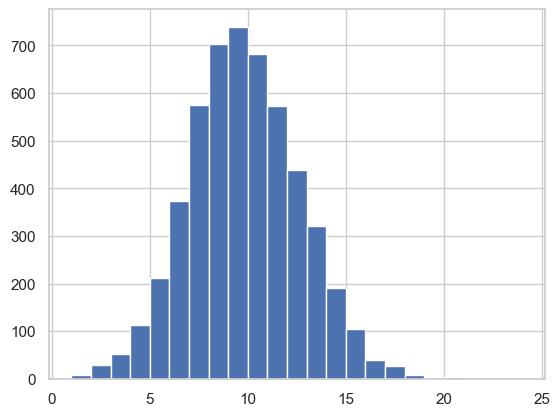

In [110]:
sentences_nbs = df_sentences.groupby("snippet_id").size()
min_nb = sentences_nbs.min()
max_nb = sentences_nbs.max()
plt.hist(sentences_nbs, bins=range(min_nb, max_nb + 1))
plt.show()

#### b) LDA with document = one sentence

In [111]:
lda_sentences = run_lda_topic_model(
    df_sentences,
    stop_words=STOP_WORDS,
    candidate_topic_counts=ALL_LDA_TOPIC_COUNTS,
    group_label="sentence-level snippets",
    id_col="sentence_id",
    random_state=RANDOM_STATE,
    n_jobs=6,
    min_docs=50,
    min_df=5,
)

lda_sentences["scores"]

,n_topics,perplexity,log_likelihood
0,2,6002.716550,-3.217683e+06
1,3,6337.664220,-3.237765e+06
2,4,6657.192413,-3.255957e+06
3,5,6940.180175,-3.271354e+06
4,6,7117.992889,-3.280710e+06
5,7,7287.939348,-3.289437e+06
6,8,7449.353884,-3.297539e+06
7,9,7568.004020,-3.303384e+06
8,10,7671.901880,-3.308427e+06
9,11,7789.344677,-3.314045e+06


In [112]:
lda_sentences["summary"]

,model_group,dominant_topic,n_documents,mean_weight,n_books,top_terms
1,sentence-level snippets,1,25400,0.779186,2124,"day, good, mind, great, world, years, new, work, old, love, people, drug"
0,sentence-level snippets,0,23015,0.767656,2022,"room, eyes, face, night, hand, house, head, old, looked, away, door, long"


In [113]:
#representative_lda_documents(lda_sentences["assignments"], topic_id=0, n=10)

In [114]:
if EXPORT_RESULTS:
    save_model_outputs(
        OUTPUT_DIR,
        "sentence_level_lda",
        topics=lda_sentences["topics"],
        summary=lda_sentences["summary"],
        assignments=lda_sentences["assignments"],
        scores=lda_sentences["scores"],
    )

#### c) BERTopic with document = one sentence

The first sentence-level BERTopic run on all split sentences produced some useful topics, but also very large generic clusters because many sentences in each snippet are only loose narrative context. The tuned run below keeps the sentence containing an opium-related target term plus one neighboring sentence on each side, then tests several HDBSCAN cluster-size settings without reducing topics afterward.

In [115]:
df_sentence_context = add_keyword_context_flags(
    df_sentences,
    keywords=keyword_terms,
    text_col="Snippet",
    window=SENTENCE_CONTEXT_WINDOW,
)
df_sentence_context = df_sentence_context.loc[df_sentence_context["near_target_term"]].copy().reset_index(drop=True)

print(f"All sentence documents: {len(df_sentences):,}")
print(f"Keyword-context sentence documents: {len(df_sentence_context):,}")
print(f"Direct keyword sentence documents: {df_sentence_context['contains_target_term'].sum():,}")

df_sentence_context[["sentence_id", "snippet_id", "Keyword", "contains_target_term", "Snippet"]].head()

All sentence documents: 48,415
Keyword-context sentence documents: 17,217
Direct keyword sentence documents: 6,295


,sentence_id,snippet_id,Keyword,contains_target_term,Snippet
0,0_3,0,opium,False,"“Why, thou monkey,” said a harpooneer to one of these lads, “we’ve been cruising now hard upon three years, and thou hast not raised a whale yet."
1,0_4,0,opium,True,Whales are scarce as hen’s teeth whenever thou art up here.” Perhaps they were; or perhaps there might have been shoals of them in the far horizon; but lulled into such an opiu...
2,0_5,0,opium,False,"In this enchanted mood, thy spirit ebbs away to whence it came; becomes diffused through time and"
3,1_2,1,paregoric,False,"His spout was short, slow, and laborious; coming forth with a choking sort of gush, and spending itself in torn shreds, followed by strange subterranean commotions in him, whic..."
4,1_3,1,paregoric,True,"“Who’s got some paregoric ?” said Stubb, “he has the stomach-ache, I’m afraid."


In [116]:
SENTENCE_EXTRA_STOP_WORDS = {
    "old", "good", "great", "little", "long", "look", "looked", "looking", "saw",
    "eyes", "face", "hand", "head", "hands", "room", "door", "house", "place",
    "day", "came", "went", "got", "asked", "answered", "replied", "told", "said",
    "says", "sir", "mr", "mrs", "miss", "thing", "things", "people", "man", "men",
    "woman", "women", "girl", "boy", "father", "mother", "friend", "dear", "poor",
}

SENTENCE_CONTEXT_STOP_WORDS = sorted(
    set(build_stop_words(df_sentence_context["Snippet"], keywords=keyword_terms, min_document_share=0.12))
    #| SENTENCE_EXTRA_STOP_WORDS
)

print(f"Sentence-context stop words: {len(SENTENCE_CONTEXT_STOP_WORDS):,}")

Sentence-context stop words: 368


In [117]:
if RUN_SENTENCE_BERTOPIC_TUNING:
    if SENTENCE_CONTEXT_EMBEDDINGS.exists():
        sentence_context_embeddings = np.load(SENTENCE_CONTEXT_EMBEDDINGS)
        if len(sentence_context_embeddings) != len(df_sentence_context):
            sentence_context_embeddings = None
    else:
        sentence_context_embeddings = None

    if sentence_context_embeddings is None:
        sentence_encoder = SentenceTransformer(SENTENCE_LEVEL_EMBEDDING_MODEL)
        sentence_context_embeddings = sentence_encoder.encode(
            df_sentence_context["document"].tolist(),
            batch_size=64,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        np.save(SENTENCE_CONTEXT_EMBEDDINGS, sentence_context_embeddings)
else:
    sentence_context_embeddings = None

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/270 [00:00<?, ?it/s]

In [118]:
# ~ 2 min
tuned_sentence_results = {}
tuned_sentence_diagnostics = []

if RUN_SENTENCE_BERTOPIC_TUNING:
    for config in TUNED_SENTENCE_BERTOPIC_CONFIGS:
        print(f"Fitting {config['name']}...")
        umap_model = UMAP(
            n_neighbors=config["n_neighbors"],
            n_components=5,
            min_dist=0.0,
            metric="cosine",
            random_state=RANDOM_STATE,
        )
        hdbscan_model = HDBSCAN(
            min_cluster_size=config["min_cluster_size"],
            min_samples=config["min_samples"],
            metric="euclidean",
            cluster_selection_method="leaf", # "most fine grained and homogeneous clusters"
            prediction_data=False,
        )

        result = run_bertopic_model(
            df_sentence_context,
            stop_words=SENTENCE_CONTEXT_STOP_WORDS,
            embedding_model=SENTENCE_LEVEL_EMBEDDING_MODEL,
            embeddings=sentence_context_embeddings,
            group_label=config["name"],
            text_col="document",
            id_col="sentence_id",
            min_docs=50,
            min_topic_size=config["min_cluster_size"],
            nr_topics=None, # None gave 60 good topics, slighty duplicated using context_leaf_mcs60_ms1_nn10
            calculate_probabilities=False,
            vectorizer_min_df=1,
            vectorizer_max_df=0.90,
            vectorizer_ngram_range=(1, 3),
            verbose=False,
            bertopic_kwargs={
                "umap_model": umap_model,
                "hdbscan_model": hdbscan_model,
                "ctfidf_model": ClassTfidfTransformer(reduce_frequent_words=True),
            },
        )
        tuned_sentence_results[config["name"]] = result

        diagnostics = bertopic_size_diagnostics(
            result["summary"],
            total_documents=len(df_sentence_context),
            rich_topic_min_size=30,
            rich_topic_max_size=400,
        )
        diagnostics.update(config)
        tuned_sentence_diagnostics.append(diagnostics)

        if EXPORT_RESULTS:
            save_model_outputs(
                OUTPUT_DIR,
                f"tuned_sentence_bertopic_{config['name']}",
                topics=result["topics"],
                summary=result["summary"],
                assignments=result["assignments"],
                topic_info=result["topic_info"],
            )

tuned_sentence_diagnostics = pd.DataFrame(tuned_sentence_diagnostics)
if not tuned_sentence_diagnostics.empty:
    tuned_sentence_diagnostics = tuned_sentence_diagnostics.sort_values(
        ["largest_topic_share", "outlier_share", "n_rich_sized_topics"],
        ascending=[True, True, False],
    )
    if EXPORT_RESULTS:
        tuned_sentence_diagnostics.to_csv(OUTPUT_DIR / "tuned_sentence_bertopic_diagnostics.csv", index=False)

tuned_sentence_diagnostics

Fitting context_leaf_mcs80_ms1_nn12...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Fitting context_leaf_mcs60_ms1_nn10...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Fitting context_leaf_mcs40_ms1_nn10...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Fitting context_leaf_mcs30_ms1_nn8...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,n_topics,outlier_documents,outlier_share,largest_topic_documents,largest_topic_share,n_rich_sized_topics,median_topic_size,name,min_cluster_size,min_samples,n_neighbors
2,91,9178,0.533078,318,0.018470,91,71.0,context_leaf_mcs40_ms1_nn10,40,1,10
3,126,8512,0.494395,364,0.021142,126,53.5,context_leaf_mcs30_ms1_nn8,30,1,8
1,58,8806,0.511471,570,0.033107,57,118.0,context_leaf_mcs60_ms1_nn10,60,1,10
0,44,8344,0.484637,843,0.048963,41,153.0,context_leaf_mcs80_ms1_nn12,80,1,12


In [119]:
if RUN_SENTENCE_BERTOPIC_TUNING:
    eligible_tuned_models = tuned_sentence_diagnostics.loc[
        (tuned_sentence_diagnostics["largest_topic_share"] <= 0.25)
        & (tuned_sentence_diagnostics["n_topics"] >= 8)
    ].copy()
    if eligible_tuned_models.empty:
        selected_sentence_config = tuned_sentence_diagnostics.iloc[0]["name"]
    else:
        selected_sentence_config = (
            eligible_tuned_models
            .sort_values(["outlier_share", "n_rich_sized_topics", "largest_topic_share"], ascending=[True, False, True])
            .iloc[0]["name"]
        )
    bertopic_sentences = tuned_sentence_results[selected_sentence_config]
else:
    selected_sentence_config = "sentence_context_bertopic_tuned_final"
    bertopic_sentences = {
        "topics": pd.read_csv(OUTPUT_DIR / "sentence_context_bertopic_tuned_final_topics_terms.csv"),
        "summary": pd.read_csv(OUTPUT_DIR / "sentence_context_bertopic_tuned_final_topic_summary.csv"),
        "assignments": pd.read_csv(OUTPUT_DIR / "sentence_context_bertopic_tuned_final_document_topics.csv"),
        "topic_info": pd.read_csv(OUTPUT_DIR / "sentence_context_bertopic_tuned_final_topic_info.csv"),
    }

print(f"Selected tuned sentence BERTopic model: {selected_sentence_config}")
bertopic_sentences["topic_info"]

Selected tuned sentence BERTopic model: context_leaf_mcs80_ms1_nn12


,model_group,Topic,Count,Name,Representation,Representative_Docs
0,context_leaf_mcs80_ms1_nn12,-1,8344,-1_room_eyes_good_house,"[room, eyes, good, house, woman, great, away, face, hand, saw, death, small]",[its natural history with due details of all manner of poppies their indigenous habitats botanical characters ratios of increase and the like its human history discovery as a d...
1,context_leaf_mcs80_ms1_nn12,0,843,0_habit_smoking_drug_eater,"[habit, smoking, drug, eater, doc, drink, smoker, taking, use, money, gave, pipe]",[he had no public he was poor infirm homeless loveless travel and adventure were cut off from him and he had no minor risks to run the cruel necessities of labor sapped his dre...
2,context_leaf_mcs80_ms1_nn12,1,477,1_truth_kai lung_power_kai,"[truth, kai lung, power, kai, story, misery, lung, nature, bitter, meant, sense, mind]",[he had of late taken pains to inform himself of the experience of others who had passed down the same dark slippery path and when he tried to diminish instead of increasing hi...
3,context_leaf_mcs80_ms1_nn12,2,439,2_dream_god_fear_art,"[dream, god, fear, art, church, spiritual, mind, love, religion, christ, misery, faith]",[the church is made gorgeous with soft lights and colours glorious music resounds through the building and the mind drowses gently under the influence of the latin chanting whi...
4,context_leaf_mcs80_ms1_nn12,3,344,3_bottle_dose_drops_doctor,"[bottle, dose, drops, doctor, chemist, pint, weak, vial, phial, spirits, poured, taken]",[and you remember from the eleventh book in its earlier part that laudanum already existed in eden nay that it was used medicinally by an archangel for after michael had purged...
5,context_leaf_mcs80_ms1_nn12,4,335,4_face_door_eyes_chair,"[face, door, eyes, chair, head, clothes, flung, wore, floor, open, hat, foot]",[unintelligible as he watches the spasmodic shoots and darts that break out of her face and limbs like fitful lightning out of a dark sky some contagion in them seizes upon him...
6,context_leaf_mcs80_ms1_nn12,5,327,5_doctor_physician_fever_ill,"[doctor, physician, fever, ill, patient, surgeon, symptoms, medical, morrhage, hospital, wounds, stomach]",[corporal mulligan a basin and sponge and desire dr i did not catch the name to step this way the corporal a black bearded connaught ranger who had lost an eye at alma brought ...
7,context_leaf_mcs80_ms1_nn12,6,311,6_rita_gretna_mollie_mollie gretna,"[rita, gretna, mollie, mollie gretna, insane, husband, eater, pipe, wild, smoked, poppies, surely rita pipe]",[it wasn t right old fellow you oughtn t then he gave it up and smiled helplessly you belong my good friend tsang what thing you wantchee a slow smile broke the brass like stil...
8,context_leaf_mcs80_ms1_nn12,7,305,7_diphtheria_died_sloane_death,"[diphtheria, died, sloane, death, caused death, caused, illness, mabel, died poisoning, taken, disease, dose]",[what is your opinion of that i found evidences in the throat and adjacent parts that the woman had had diphtheria but from the total absence of false membrane i should say tha...
9,context_leaf_mcs80_ms1_nn12,8,302,8_poetry_poems_literary_book,"[poetry, poems, literary, book, poet, prose, literature, poets, genius, wrote, essays, keats]",[one individual in particular a man of genuine literary and critical ability and great taste in the matter of all the arts but with no least interest in or tolerance for the si...


In [120]:
df_sentences[df_sentences["Book_ID"] == 55276]

,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name,snippet_id,document,LoCC_group,Period,sentence_id,sentence_number
40305,5680,55276,opium,"“When I came here, the first time, the first day, and saw you sitting in her chair, at her table, in her attitude, as I said, it was a reincarnation.” He got up from the music ...",55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,when i came here the first time the first day and saw you sitting in her chair at her table in her attitude as i said it was a reincarnation he got up from the music stool and ...,English Literature,1910-1929,4529_0,0
40306,5680,55276,opium,"He said, without preliminary or excuse, “You are taking opium in some form or other.” “I am taking my medicine.” “I am not blaming you.",55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,he said without preliminary or excuse you are taking opium in some form or other i am taking my medicine i am not blaming you,English Literature,1910-1929,4529_1,1
40307,5680,55276,opium,"You’ve read De Quincey, haven’t you?",55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,you ve read de quincey haven t you,English Literature,1910-1929,4529_2,2
40308,5680,55276,opium,"You know his theory?” “Some of it.” “Never mind; perhaps you’ve missed it, better if you have.",55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,you know his theory some of it never mind perhaps you ve missed it better if you have,English Literature,1910-1929,4529_3,3
40309,5680,55276,opium,In those days it was often thought that opium cured consumption.” “Then it is consumption?” “What does it matter what we call it?,55276,"Frankau, Julia",PR,1926,NaN,Male,Anonymous,4529,in those days it was often thought that opium cured consumption then it is consumption what does it matter what we call it,English Literature,1910-1929,4529_4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40517,5704,55276,codein,No extra codein for me any more.,55276,"Frankau, Julia",PR,1926,NaN,Female,Margaret,4547,no extra codein for me any more,English Literature,1910-1929,4547_7,7
40518,5704,55276,codein,"I no longer wanted to dream, only to face what was before me with courage.",55276,"Frankau, Julia",PR,1926,NaN,Female,Margaret,4547,i no longer wanted to dream only to face what was before me with courage,English Literature,1910-1929,4547_8,8
40519,5704,55276,codein,"My writing-block was by my side and pencils, one of Ella’s last gifts, and I drew them toward me.",55276,"Frankau, Julia",PR,1926,NaN,Female,Margaret,4547,my writing block was by my side and pencils one of ella s last gifts and i drew them toward me,English Literature,1910-1929,4547_9,9
40520,5704,55276,codein,"I had to break to her that if she would be lonely in the world without me, then it was time for her to prepare for loneliness.",55276,"Frankau, Julia",PR,1926,NaN,Female,Margaret,4547,i had to break to her that if she would be lonely in the world without me then it was time for her to prepare for loneliness,English Literature,1910-1929,4547_10,10


In [121]:
mask = ["fear" in doc.split(' ') for doc in df_sentences["document"]]
df_sentences[mask]

,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name,snippet_id,document,LoCC_group,Period,sentence_id,sentence_number
468,63,155,opium,"Otherwise, I should be inclined to fear that he will be totally unfit for the experiment when the time comes to try it.",155,"Collins, Wilkie",PR,1868,female,Female,Anonymous,49,otherwise i should be inclined to fear that he will be totally unfit for the experiment when the time comes to try it,English Literature,1850-1869,49_0,0
930,114,155,laudanum,In the fear of an accident happening he followed you softly to see what you would do.,155,"Collins, Wilkie",PR,1868,female,Male,Verinder,88,in the fear of an accident happening he followed you softly to see what you would do,English Literature,1850-1869,88_6,6
1132,133,173,opium,The fierce resentment born of dreadful wrongs was consuming her now; but fear of Fu-Manchu held her yet.,173,"Rohmer, Sax",PR,1913,male,Unknown,Anonymous,107,the fierce resentment born of dreadful wrongs was consuming her now but fear of fu manchu held her yet,English Literature,1910-1929,107_11,11
1856,214,345,narcotic,"“Do not stir,” he said, “but I fear that with growing strength she may wake; and that would make danger, oh, so much danger.",345,"Stoker, Bram",PR,1897,male,Male,Lucy,179,do not stir he said but i fear that with growing strength she may wake and that would make danger oh so much danger,English Literature,1890-1909,179_1,1
2171,258,464,opium,"We were to grow better acquainted, and first and last I had the same impression; he seemed always drowsy, yet always to hearken and start; and, whether from remorse or fear, th...",464,"Stevenson, Robert Louis",PR,1888,male,Male,Anonymous,211,we were to grow better acquainted and first and last i had the same impression he seemed always drowsy yet always to hearken and start and whether from remorse or fear there is...,English Literature,1870-1889,211_4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47322,6529,72609,soporific,"The church and Sunday School at Elmer’s village, Paris, Kansas, a settlement of nine hundred evangelical Germans and Vermonters, had nurtured in him a fear of religious machine...",72609,"Lewis, Sinclair",PS,1926,male,Male,Missionary Suppers,5257,the church and sunday school at elmer s village paris kansas a settlement of nine hundred evangelical germans and vermonters had nurtured in him a fear of religious machinery w...,American Literature,1910-1929,5257_1,1
47717,6578,72849,opium,"First, the bartender scowled at him and asked what he would take, and when he refused to take anything, having a just fear that any liquor sold in such a place would be only le...",72849,"Lynde, Francis",PS,1916,male,Male,Forsyth,5298,first the bartender scowled at him and asked what he would take and when he refused to take anything having a just fear that any liquor sold in such a place would be only less ...,American Literature,1910-1929,5298_7,7
48133,6628,73254,opium,One thing was certain: there was not a trace of fear in his manner though it seemed to me he was rather curious as to who Bartley might be.,73254,"Dutton, Charles J. (Charles Judson)",PS,1926,NaN,Male,Chinaman,5343,one thing was certain there was not a trace of fear in his manner though it seemed to me he was rather curious as to who bartley might be,American Literature,1910-1929,5343_1,1
48307,6645,73409,anodyne,He had no longer to fear that awful suspense which had the power to overthrow the firmest intelligence.,73409,"Snaith, J. C. (John Collis)",PR,1923,male,Male,Anonymous,5358,he had no longer to fear that awful suspense which had the power to overthrow the firmest intelligence,English Literature,1910-1929,5358_12,12


In [122]:
if EXPORT_RESULTS:
    save_model_outputs(
        OUTPUT_DIR,
        "sentence_context_bertopic_tuned_final",
        topics=bertopic_sentences["topics"],
        summary=bertopic_sentences["summary"],
        assignments=bertopic_sentences["assignments"],
        topic_info=bertopic_sentences["topic_info"],
    )

## 4) Topic distribution by Gender

The final sentence-level BERTopic model is now treated as a shared topic space. The cells below do not fit new models; they only compare how the final topics are distributed across metadata groups. Unless stated otherwise, topic `-1` is excluded from the percentage denominators because it is the BERTopic outlier bucket.

In [123]:
FINAL_TOPIC_ASSIGNMENTS_PATH = OUTPUT_DIR / "sentence_context_bertopic_tuned_final_document_topics.csv"
FINAL_TOPIC_TERMS_PATH = OUTPUT_DIR / "sentence_context_bertopic_tuned_final_topics_terms.csv"

if "bertopic_sentences" in globals() and isinstance(bertopic_sentences, dict):
    df_final_topics = bertopic_sentences["assignments"].copy()
    final_topic_terms = bertopic_sentences["topics"].copy()
else:
    df_final_topics = pd.read_csv(FINAL_TOPIC_ASSIGNMENTS_PATH)
    final_topic_terms = pd.read_csv(FINAL_TOPIC_TERMS_PATH)

df_final_topics = add_topic_labels(
    df_final_topics,
    final_topic_terms,
    assignment_topic_col="bertopic_topic",
    topic_col="topic",
    terms_col="top_terms",
    max_terms=5,
)

df_final_topics["Author_Gender_Group"] = (
    df_final_topics["Author Gender"]
    .fillna("Unknown")
    .replace("", "Unknown")
    .astype(str)
    .str.strip()
    .str.title()
)
df_final_topics["Assigned_Gender_Group"] = (
    df_final_topics["Assigned_Gender"]
    .fillna("Unknown")
    .replace("", "Unknown")
    .astype(str)
    .str.strip()
)
df_final_topics["LoCC_Display"] = (
    df_final_topics["LoCC"]
    .fillna("Unknown")
    .replace("", "Unknown")
    .astype(str)
    .str.strip()
)
df_final_topics["Period"] = df_final_topics["Period"].astype("string")

outlier_mask = df_final_topics["bertopic_topic"].astype(int).eq(-1)
topic_assignment_sanity = pd.DataFrame({
    "metric": [
        "n_sentence_contexts",
        "n_snippets",
        "n_books",
        "outlier_sentence_contexts",
        "outlier_share",
    ],
    "value": [
        df_final_topics["sentence_id"].nunique(),
        df_final_topics["snippet_id"].nunique(),
        df_final_topics["Book_ID"].nunique(),
        int(outlier_mask.sum()),
        outlier_mask.mean(),
    ],
})
topic_assignment_sanity

,metric,value
0,n_sentence_contexts,17217.000000
1,n_snippets,5116.000000
2,n_books,2142.000000
3,outlier_sentence_contexts,8344.000000
4,outlier_share,0.484637


In [124]:
def plot_topic_distribution_heatmap(
    distribution,
    group_cols,
    title,
    top_n_topics=20,
    min_group_total=1,
    figsize=(12, 8),
):
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    plot_df = distribution.loc[distribution["group_total"] >= min_group_total].copy()
    if len(group_cols) == 1:
        plot_df["group_label"] = plot_df[group_cols[0]].astype(str)
    else:
        plot_df["group_label"] = plot_df[group_cols].astype(str).agg(" | ".join, axis=1)

    top_labels = (
        plot_df.groupby("topic_label")["n_documents"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n_topics)
        .index
    )
    plot_df = plot_df.loc[plot_df["topic_label"].isin(top_labels)]
    pivot = plot_df.pivot_table(
        index="topic_label",
        columns="group_label",
        values="topic_share",
        fill_value=0,
        aggfunc="sum",
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    plt.figure(figsize=figsize)
    sns.heatmap(pivot, cmap="Blues", annot=True, fmt=".1%", cbar_kws={"label": "Topic share"})
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Final topic")
    plt.tight_layout()
    return pivot


def metadata_topic_counts(df, group_col):
    return (
        df.groupby(group_col)
        .agg(
            n_sentence_contexts=("sentence_id", "nunique"),
            n_snippets=("snippet_id", "nunique"),
            n_books=("Book_ID", "nunique"),
            outlier_share=("bertopic_topic", lambda s: (s.astype(int) == -1).mean()),
        )
        .reset_index()
        .sort_values("n_sentence_contexts", ascending=False)
    )

### a) Author gender

In [125]:
author_gender_counts = metadata_topic_counts(df_final_topics, "Author_Gender_Group")
author_gender_counts

,Author_Gender_Group,n_sentence_contexts,n_snippets,n_books,outlier_share
1,Male,11568,3416,1421,0.478129
0,Female,3712,1129,515,0.503233
2,Unknown,1937,571,206,0.487868


,Author_Gender_Group,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,Unknown,0,"0: habit, smoking, drug, eater, doc",77,992,0.077621
1,Unknown,8,"8: poetry, poems, literary, book, poet",61,992,0.061492
2,Unknown,2,"2: dream, god, fear, art, church",59,992,0.059476
3,Unknown,1,"1: truth, kai lung, power, kai, story",49,992,0.049395
4,Unknown,10,"10: drink, wine, brandy, poison, drunk",45,992,0.045363
5,Unknown,21,"21: quincey, eater, thomas quincey, confessions, english eater",43,992,0.043347
6,Unknown,18,"18: coleridge, wordsworth, southey, sqq, gillman",37,992,0.037298
7,Unknown,5,"5: doctor, physician, fever, ill, patient",33,992,0.033266
8,Unknown,12,"12: captain, ship, colonel, schooner, ships",33,992,0.033266
9,Unknown,7,"7: diphtheria, died, sloane, death, caused death",31,992,0.031250


group_label,Female,Male,Unknown
topic_label,,,
"0: habit, smoking, drug, eater, doc",0.095445,0.097731,0.077621
"1: truth, kai lung, power, kai, story",0.052603,0.054829,0.049395
"2: dream, god, fear, art, church",0.040672,0.050522,0.059476
"8: poetry, poems, literary, book, poet",0.027115,0.031638,0.061492
"3: bottle, dose, drops, doctor, chemist",0.051518,0.036608,0.028226
"6: rita, gretna, mollie, mollie gretna, insane",0.052603,0.030479,0.030242
"5: doctor, physician, fever, ill, patient",0.033623,0.038430,0.033266
"7: diphtheria, died, sloane, death, caused death",0.040672,0.032963,0.031250
"10: drink, wine, brandy, poison, drunk",0.019523,0.032466,0.045363


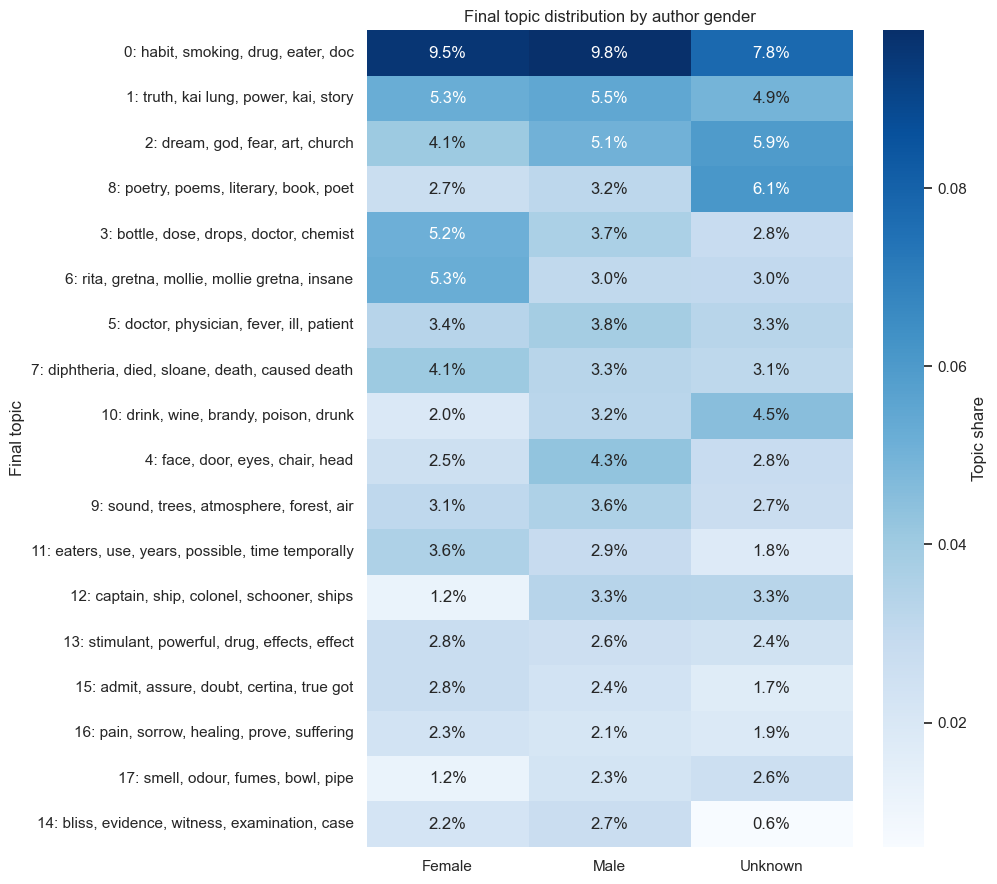

In [126]:
author_gender_topic_distribution = topic_distribution(
    df_final_topics,
    group_cols="Author_Gender_Group",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
author_gender_top_topics = top_topics_by_group(author_gender_topic_distribution, "Author_Gender_Group", n_topics=12)

display(author_gender_top_topics)
plot_topic_distribution_heatmap(
    author_gender_topic_distribution,
    "Author_Gender_Group",
    "Final topic distribution by author gender",
    top_n_topics=18,
    figsize=(10, 9),
)

### b) Assigned gender

In [127]:
assigned_gender_counts = metadata_topic_counts(df_final_topics, "Assigned_Gender_Group")
assigned_gender_counts

,Assigned_Gender_Group,n_sentence_contexts,n_snippets,n_books,outlier_share
1,Male,9092,2681,1322,0.477343
2,Unknown,3756,1119,727,0.509851
0,Female,3206,971,616,0.486276
3,Unknown (Proper Noun),1163,345,232,0.455718


,Assigned_Gender_Group,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,Unknown (Proper Noun),21,"21: quincey, eater, thomas quincey, confessions, english eater",64,633,0.101106
1,Unknown (Proper Noun),24,"24: confessions, english eater, confessions english eater, confessions english, eater",52,633,0.082148
2,Unknown (Proper Noun),40,"40: william, dickens, classics, thomas, english",50,633,0.078989
3,Unknown (Proper Noun),8,"8: poetry, poems, literary, book, poet",49,633,0.077409
4,Unknown (Proper Noun),3,"3: bottle, dose, drops, doctor, chemist",38,633,0.060032
5,Unknown (Proper Noun),43,"43: white bees, bees, sweet, love, song",30,633,0.047393
6,Unknown (Proper Noun),2,"2: dream, god, fear, art, church",25,633,0.039494
7,Unknown (Proper Noun),0,"0: habit, smoking, drug, eater, doc",21,633,0.033175
8,Unknown (Proper Noun),5,"5: doctor, physician, fever, ill, patient",21,633,0.033175
9,Unknown (Proper Noun),28,"28: pure food law, food law, pure food, got sort, tablets",21,633,0.033175


group_label,Female,Male,Unknown,Unknown (Proper Noun)
topic_label,,,,
"0: habit, smoking, drug, eater, doc",0.014572,0.155303,0.032591,0.033175
"2: dream, god, fear, art, church",0.030965,0.040404,0.092884,0.039494
"7: diphtheria, died, sloane, death, caused death",0.128112,0.008418,0.023357,0.017378
"6: rita, gretna, mollie, mollie gretna, insane",0.116576,0.014731,0.020641,0.017378
"3: bottle, dose, drops, doctor, chemist",0.022465,0.043140,0.034764,0.060032
"8: poetry, poems, literary, book, poet",0.007893,0.036616,0.035850,0.077409
"9: sound, trees, atmosphere, forest, air",0.021858,0.023990,0.070614,0.031596
"1: truth, kai lung, power, kai, story",0.014572,0.082702,0.023357,0.026856
"5: doctor, physician, fever, ill, patient",0.015179,0.046086,0.033677,0.033175


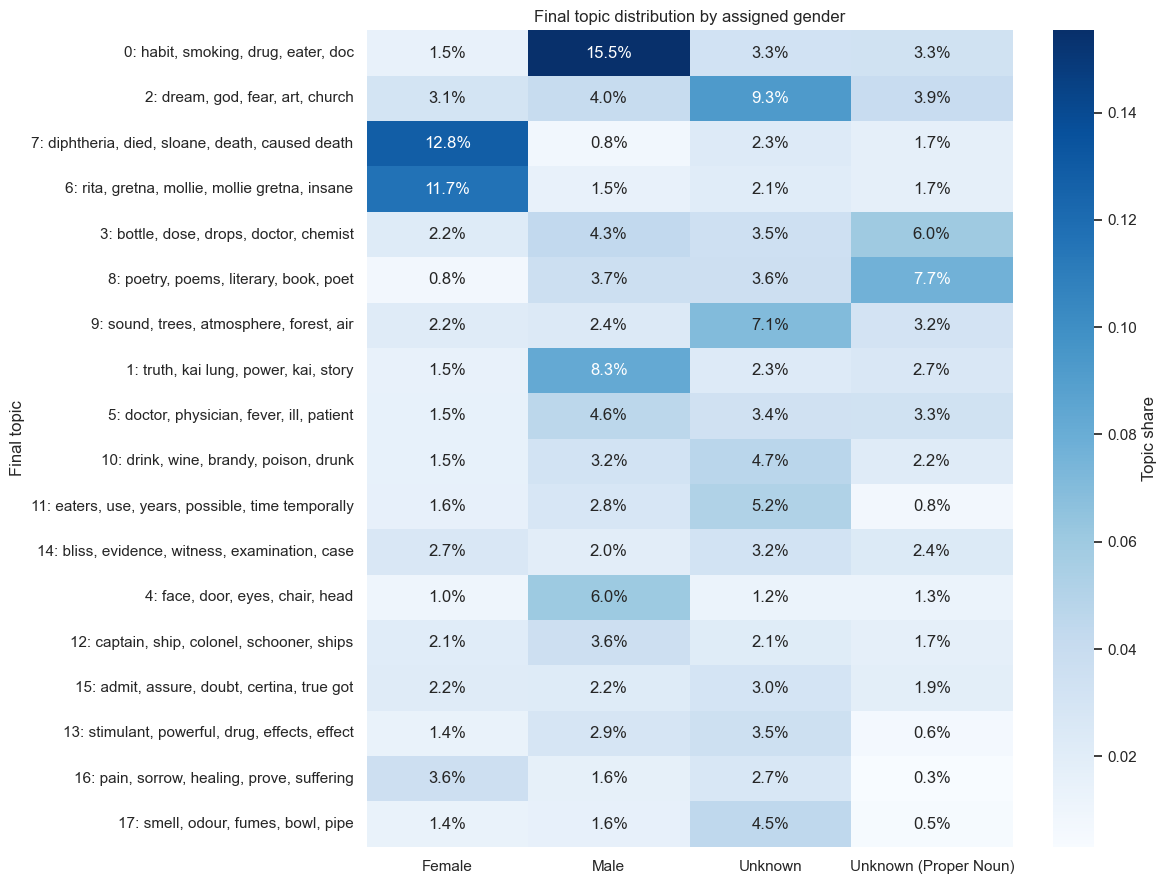

In [128]:
assigned_gender_topic_distribution = topic_distribution(
    df_final_topics,
    group_cols="Assigned_Gender_Group",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
assigned_gender_top_topics = top_topics_by_group(assigned_gender_topic_distribution, "Assigned_Gender_Group", n_topics=12)

display(assigned_gender_top_topics)
plot_topic_distribution_heatmap(
    assigned_gender_topic_distribution,
    "Assigned_Gender_Group",
    "Final topic distribution by assigned gender",
    top_n_topics=18,
    figsize=(12, 9),
)

In [129]:
if EXPORT_RESULTS:
    author_gender_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_author_gender.csv", index=False)
    assigned_gender_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_assigned_gender.csv", index=False)
    author_gender_counts.to_csv(OUTPUT_DIR / "final_topic_author_gender_counts.csv", index=False)
    assigned_gender_counts.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_counts.csv", index=False)

## 5) Topic distribution by Nationality

`LoCC` is kept as the grouping field. The heatmap uses the largest LoCC groups for readability, while the exported table keeps all LoCC values.

In [130]:
locc_counts = metadata_topic_counts(df_final_topics, "LoCC_Display")
locc_counts.head(20)

,LoCC_Display,n_sentence_contexts,n_snippets,n_books,outlier_share
18,PR,8947,2652,1065,0.477814
26,PS,7716,2294,1010,0.491835
21,PR; PZ,121,40,18,0.495868
1,AC; PS,90,27,1,0.533333
27,PZ; PS,89,29,14,0.617978
20,PR; PS,57,14,4,0.403509
14,HV; PS,39,11,1,0.179487
0,AC; PR,27,9,1,0.481481
16,PN; PR,27,9,5,0.37037
6,DA; PR,18,5,3,0.666667


,LoCC_Display,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,PZ; PS,0,"0: habit, smoking, drug, eater, doc",5,34,0.147059
1,PZ; PS,1,"1: truth, kai lung, power, kai, story",3,34,0.088235
2,PZ; PS,4,"4: face, door, eyes, chair, head",3,34,0.088235
3,PZ; PS,7,"7: diphtheria, died, sloane, death, caused death",3,34,0.088235
4,PZ; PS,19,"19: sleep, slept, awake, sleeping, gerald",3,34,0.088235
5,PZ; PS,11,"11: eaters, use, years, possible, time temporally",2,34,0.058824
6,PZ; PS,23,"23: dens, den, scandal, smuggle, smuggling",2,34,0.058824
7,PZ; PS,29,"29: fiend, bobus, owen, hope, secret fiend years",2,34,0.058824
8,PZ; PS,2,"2: dream, god, fear, art, church",1,34,0.029412
9,PZ; PS,3,"3: bottle, dose, drops, doctor, chemist",1,34,0.029412


group_label,AC; PR,AC; PS,HV; PS,PR,PR; PS,PR; PZ,PS,PZ; PS
topic_label,,,,,,,,
"0: habit, smoking, drug, eater, doc",0.071429,0.119048,0.00000,0.100813,0.235294,0.032787,0.089263,0.147059
"7: diphtheria, died, sloane, death, caused death",0.000000,0.000000,0.37500,0.010702,0.000000,0.000000,0.060954,0.088235
"8: poetry, poems, literary, book, poet",0.142857,0.095238,0.00000,0.040454,0.117647,0.000000,0.023973,0.000000
"1: truth, kai lung, power, kai, story",0.000000,0.095238,0.00000,0.056935,0.029412,0.049180,0.049732,0.088235
"10: drink, wine, brandy, poison, drunk",0.142857,0.023810,0.06250,0.030608,0.000000,0.065574,0.031625,0.000000
"5: doctor, physician, fever, ill, patient",0.000000,0.166667,0.06250,0.031892,0.000000,0.016393,0.042336,0.029412
"4: face, door, eyes, chair, head",0.142857,0.023810,0.00000,0.032748,0.000000,0.016393,0.044631,0.088235
"12: captain, ship, colonel, schooner, ships",0.071429,0.000000,0.00000,0.018622,0.000000,0.131148,0.040806,0.029412
"13: stimulant, powerful, drug, effects, effect",0.071429,0.047619,0.00000,0.026755,0.000000,0.065574,0.024484,0.029412


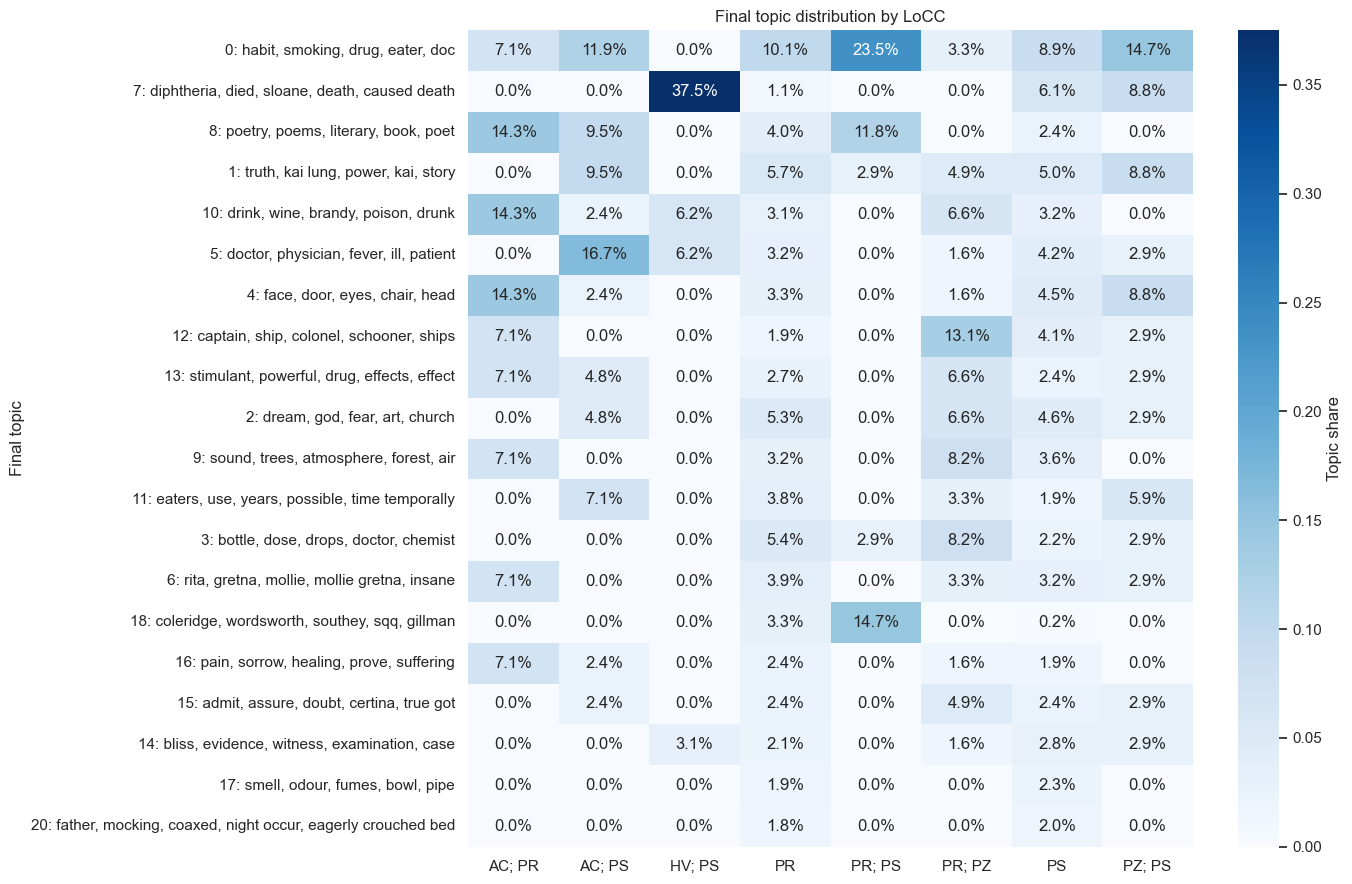

In [131]:
locc_topic_distribution = topic_distribution(
    df_final_topics,
    group_cols="LoCC_Display",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
locc_top_topics = top_topics_by_group(locc_topic_distribution, "LoCC_Display", n_topics=10)

display(locc_top_topics.head(40))
major_locc_values = locc_counts.head(8)["LoCC_Display"].tolist()
plot_topic_distribution_heatmap(
    locc_topic_distribution.loc[locc_topic_distribution["LoCC_Display"].isin(major_locc_values)],
    "LoCC_Display",
    "Final topic distribution by LoCC",
    top_n_topics=20,
    figsize=(14, 9),
)

In [132]:
if EXPORT_RESULTS:
    locc_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_locc.csv", index=False)
    locc_counts.to_csv(OUTPUT_DIR / "final_topic_locc_counts.csv", index=False)

## 6) Topic distribution by Period

The period comparison keeps the four 20-year bins created earlier.

In [133]:
period_counts = metadata_topic_counts(df_final_topics, "Period")
period_counts

,Period,n_sentence_contexts,n_snippets,n_books,outlier_share
3,1910-1929,7154,2114,840,0.496366
2,1890-1909,5854,1739,782,0.47916
1,1870-1889,2198,676,315,0.465423
0,1850-1869,2011,587,205,0.479861


,Period,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,1910-1929,0,"0: habit, smoking, drug, eater, doc",378,3603,0.104913
1,1910-1929,1,"1: truth, kai lung, power, kai, story",187,3603,0.051901
2,1910-1929,4,"4: face, door, eyes, chair, head",167,3603,0.046350
3,1910-1929,6,"6: rita, gretna, mollie, mollie gretna, insane",145,3603,0.040244
4,1910-1929,2,"2: dream, god, fear, art, church",139,3603,0.038579
5,1910-1929,8,"8: poetry, poems, literary, book, poet",123,3603,0.034138
6,1910-1929,12,"12: captain, ship, colonel, schooner, ships",123,3603,0.034138
7,1910-1929,17,"17: smell, odour, fumes, bowl, pipe",117,3603,0.032473
8,1910-1929,9,"9: sound, trees, atmosphere, forest, air",111,3603,0.030808
9,1910-1929,5,"5: doctor, physician, fever, ill, patient",110,3603,0.030530


group_label,1850-1869,1870-1889,1890-1909,1910-1929
topic_label,,,,
"0: habit, smoking, drug, eater, doc",0.070746,0.096170,0.091177,0.104913
"2: dream, god, fear, art, church",0.065010,0.065532,0.050836,0.038579
"1: truth, kai lung, power, kai, story",0.047801,0.067234,0.052804,0.051901
"3: bottle, dose, drops, doctor, chemist",0.086998,0.045957,0.039357,0.021926
"5: doctor, physician, fever, ill, patient",0.047801,0.048511,0.036077,0.030530
"8: poetry, poems, literary, book, poet",0.042065,0.035745,0.030502,0.034138
"6: rita, gretna, mollie, mollie gretna, insane",0.038241,0.034043,0.028206,0.040244
"11: eaters, use, years, possible, time temporally",0.057361,0.028085,0.024926,0.024702
"4: face, door, eyes, chair, head",0.017208,0.030638,0.037389,0.046350


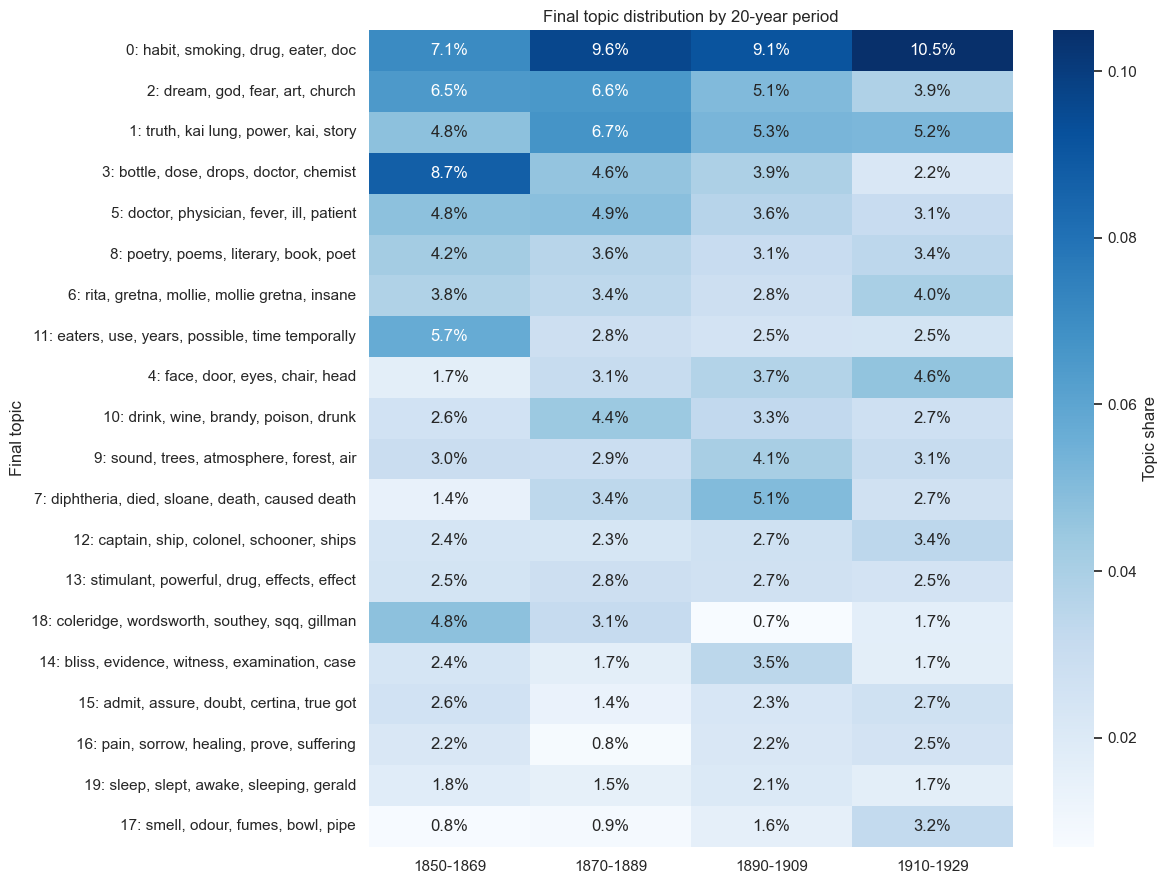

In [134]:
period_topic_distribution = topic_distribution(
    df_final_topics,
    group_cols="Period",
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
period_top_topics = top_topics_by_group(period_topic_distribution, "Period", n_topics=12)

display(period_top_topics)
plot_topic_distribution_heatmap(
    period_topic_distribution,
    "Period",
    "Final topic distribution by 20-year period",
    top_n_topics=20,
    figsize=(12, 9),
)

In [135]:
if EXPORT_RESULTS:
    period_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_period.csv", index=False)
    period_counts.to_csv(OUTPUT_DIR / "final_topic_period_counts.csv", index=False)

## 7) Combining Gender, Nationality and Period for Topic Distribution

### a) Sanity check: snippet distribution

In [136]:
combo_author_counts = (
    df_final_topics
    .groupby(["Author_Gender_Group", "LoCC_Display", "Period"])
    .agg(
        n_sentence_contexts=("sentence_id", "nunique"),
        n_snippets=("snippet_id", "nunique"),
        n_books=("Book_ID", "nunique"),
        outlier_share=("bertopic_topic", lambda s: (s.astype(int) == -1).mean()),
    )
    .reset_index()
    .sort_values("n_sentence_contexts", ascending=False)
)
combo_author_counts.head(30)

,Author_Gender_Group,LoCC_Display,Period,n_sentence_contexts,n_snippets,n_books,outlier_share
32,Male,PR,1910-1929,2522,738,274,0.511499
44,Male,PS,1910-1929,2247,666,264,0.481086
31,Male,PR,1890-1909,2095,621,297,0.461575
43,Male,PS,1890-1909,1871,538,241,0.46232
42,Male,PS,1870-1889,833,248,102,0.488595
30,Male,PR,1870-1889,794,248,113,0.459698
8,Female,PS,1890-1909,778,239,110,0.524422
3,Female,PR,1890-1909,772,239,96,0.502591
29,Male,PR,1850-1869,635,182,61,0.448819
69,Unknown,PS,1910-1929,617,175,64,0.552674


In [137]:
combo_assigned_counts = (
    df_final_topics
    .groupby(["Assigned_Gender_Group", "LoCC_Display", "Period"])
    .agg(
        n_sentence_contexts=("sentence_id", "nunique"),
        n_snippets=("snippet_id", "nunique"),
        n_books=("Book_ID", "nunique"),
        outlier_share=("bertopic_topic", lambda s: (s.astype(int) == -1).mean()),
    )
    .reset_index()
    .sort_values("n_sentence_contexts", ascending=False)
)
combo_assigned_counts.head(30)

,Assigned_Gender_Group,LoCC_Display,Period,n_sentence_contexts,n_snippets,n_books,outlier_share
35,Male,PR,1910-1929,1912,564,238,0.490063
45,Male,PS,1910-1929,1828,530,271,0.477024
34,Male,PR,1890-1909,1780,528,259,0.467978
44,Male,PS,1890-1909,1332,393,220,0.511261
66,Unknown,PR,1910-1929,864,251,144,0.532407
77,Unknown,PS,1910-1929,759,227,145,0.545455
14,Female,PS,1890-1909,670,191,105,0.429851
65,Unknown,PR,1890-1909,643,193,137,0.502333
15,Female,PS,1910-1929,625,194,126,0.5136
43,Male,PS,1870-1889,581,174,84,0.447504


### b) Author gender + LoCC + Period

In [138]:
combo_author_topic_distribution = topic_distribution(
    df_final_topics,
    group_cols=["Author_Gender_Group", "LoCC_Display", "Period"],
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
combo_author_top_topics = top_topics_by_group(
    combo_author_topic_distribution,
    ["Author_Gender_Group", "LoCC_Display", "Period"],
    n_topics=5,
)
combo_author_top_topics.head(60)

,Author_Gender_Group,LoCC_Display,Period,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,Unknown,PZ; PS,1910-1929,0,"0: habit, smoking, drug, eater, doc",2,4,0.500000
1,Unknown,PZ; PS,1910-1929,1,"1: truth, kai lung, power, kai, story",1,4,0.250000
2,Unknown,PZ; PS,1910-1929,19,"19: sleep, slept, awake, sleeping, gerald",1,4,0.250000
3,Unknown,PS,1910-1929,2,"2: dream, god, fear, art, church",23,276,0.083333
4,Unknown,PS,1910-1929,4,"4: face, door, eyes, chair, head",22,276,0.079710
5,Unknown,PS,1910-1929,0,"0: habit, smoking, drug, eater, doc",21,276,0.076087
6,Unknown,PS,1910-1929,12,"12: captain, ship, colonel, schooner, ships",18,276,0.065217
7,Unknown,PS,1910-1929,17,"17: smell, odour, fumes, bowl, pipe",17,276,0.061594
8,Unknown,PS,1890-1909,4,"4: face, door, eyes, chair, head",3,25,0.120000
9,Unknown,PS,1890-1909,10,"10: drink, wine, brandy, poison, drunk",3,25,0.120000


group_label,Female | PR | 1850-1869,Female | PR | 1870-1889,Female | PR | 1890-1909,Female | PR | 1910-1929,Female | PS | 1850-1869,Female | PS | 1870-1889,Female | PS | 1890-1909,Female | PS | 1910-1929,Male | PR | 1850-1869,Male | PR | 1870-1889,Male | PR | 1890-1909,Male | PR | 1910-1929,Male | PS | 1850-1869,Male | PS | 1870-1889,Male | PS | 1890-1909,Male | PS | 1910-1929
topic_label,,,,,,,,,,,,,,,,
"0: habit, smoking, drug, eater, doc",0.101626,0.067568,0.174479,0.097222,0.041667,0.028037,0.075676,0.056604,0.085714,0.104895,0.090426,0.105519,0.038462,0.126761,0.067594,0.126930
"1: truth, kai lung, power, kai, story",0.008130,0.067568,0.062500,0.078704,0.013889,0.009346,0.064865,0.067925,0.062857,0.062937,0.073582,0.046266,0.038462,0.096244,0.023857,0.051458
"2: dream, god, fear, art, church",0.040650,0.040541,0.049479,0.037037,0.083333,0.037383,0.035135,0.026415,0.065714,0.086247,0.062057,0.038149,0.067308,0.070423,0.043738,0.031732
"3: bottle, dose, drops, doctor, chemist",0.203252,0.054054,0.015625,0.055556,0.027778,0.009346,0.037838,0.003774,0.074286,0.048951,0.061170,0.028409,0.048077,0.053991,0.017893,0.015437
"6: rita, gretna, mollie, mollie gretna, insane",0.052846,0.040541,0.062500,0.055556,0.083333,0.065421,0.032432,0.056604,0.017143,0.034965,0.022163,0.056006,0.028846,0.025822,0.019881,0.027444
"5: doctor, physician, fever, ill, patient",0.028455,0.027027,0.031250,0.032407,0.069444,0.056075,0.035135,0.022642,0.031429,0.044289,0.025709,0.030844,0.076923,0.058685,0.052684,0.034305
"9: sound, trees, atmosphere, forest, air",0.008130,0.020270,0.023438,0.037037,0.055556,0.037383,0.029730,0.060377,0.025714,0.020979,0.050532,0.032468,0.067308,0.032864,0.042744,0.024871
"7: diphtheria, died, sloane, death, caused death",0.008130,0.047297,0.007812,0.018519,0.041667,0.112150,0.067568,0.060377,0.008571,0.000000,0.009752,0.008929,0.000000,0.018779,0.114314,0.033448
"11: eaters, use, years, possible, time temporally",0.081301,0.040541,0.062500,0.023148,0.027778,0.009346,0.005405,0.011321,0.071429,0.018648,0.020390,0.042208,0.048077,0.042254,0.021869,0.014580


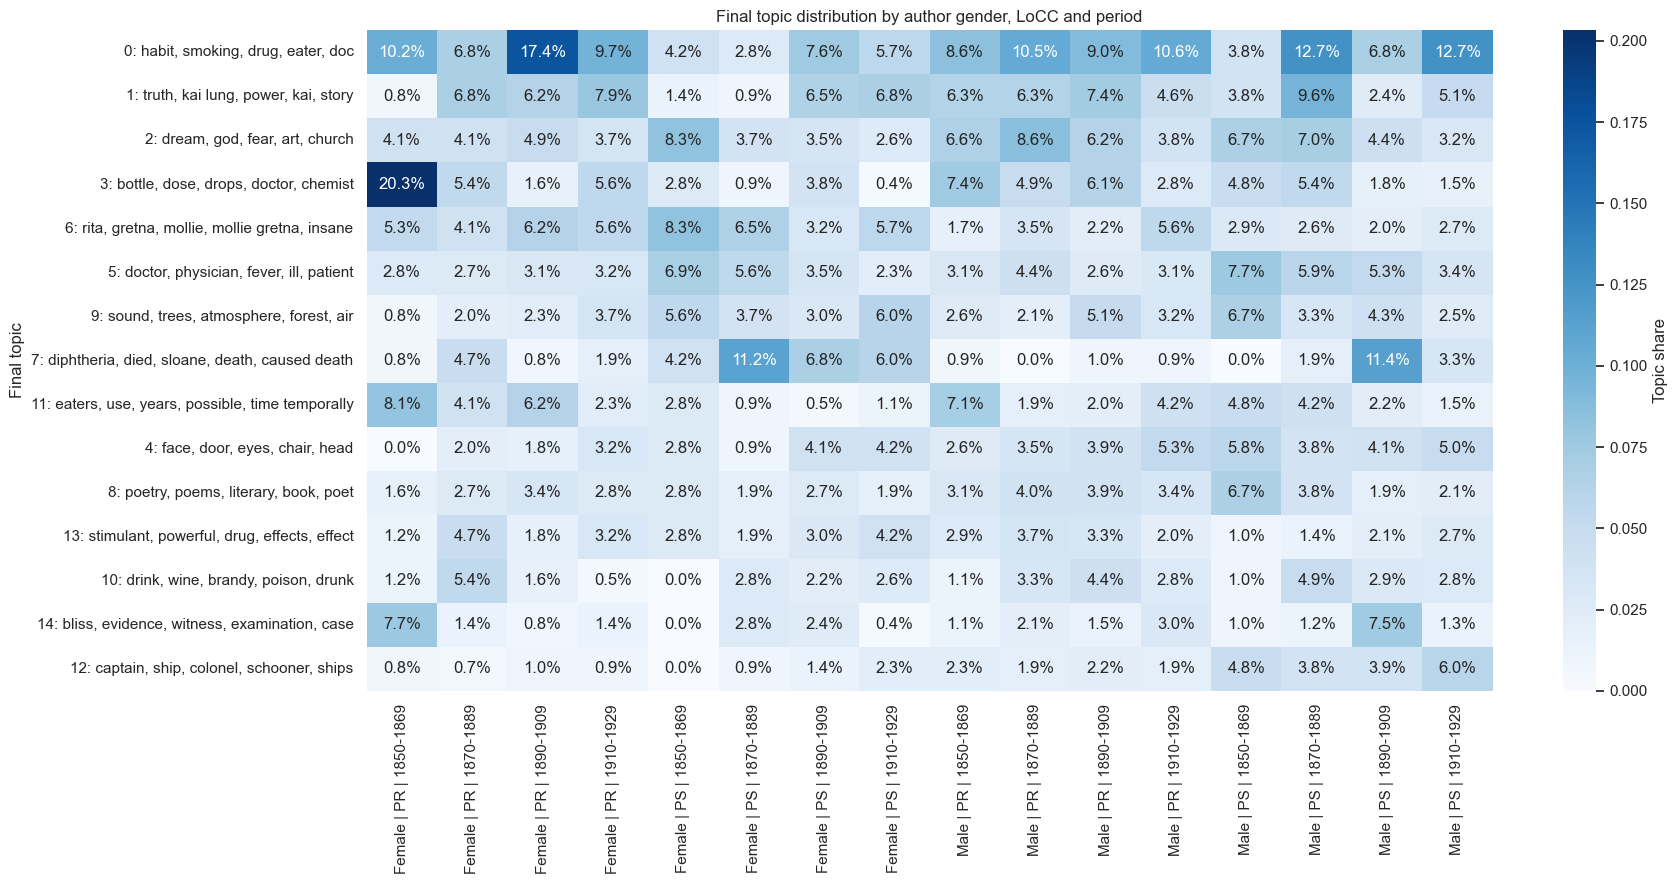

In [139]:
plot_topic_distribution_heatmap(
    combo_author_topic_distribution.loc[
        combo_author_topic_distribution["LoCC_Display"].isin(["PR", "PS"])
        & combo_author_topic_distribution["Author_Gender_Group"].isin(["Male", "Female"])
    ],
    ["Author_Gender_Group", "LoCC_Display", "Period"],
    "Final topic distribution by author gender, LoCC and period",
    top_n_topics=15,
    min_group_total=30,
    figsize=(18, 9),
)

### c) Assigned gender + LoCC + Period

In [140]:
combo_assigned_topic_distribution = topic_distribution(
    df_final_topics,
    group_cols=["Assigned_Gender_Group", "LoCC_Display", "Period"],
    topic_col="bertopic_topic",
    label_col="topic_label",
    unit_col="sentence_id",
    include_outlier=False,
)
combo_assigned_top_topics = top_topics_by_group(
    combo_assigned_topic_distribution,
    ["Assigned_Gender_Group", "LoCC_Display", "Period"],
    n_topics=5,
)
combo_assigned_top_topics.head(60)

,Assigned_Gender_Group,LoCC_Display,Period,bertopic_topic,topic_label,n_documents,group_total,topic_share
0,Unknown (Proper Noun),PS,1910-1929,28,"28: pure food law, food law, pure food, got sort, tablets",13,102,0.127451
1,Unknown (Proper Noun),PS,1910-1929,2,"2: dream, god, fear, art, church",6,102,0.058824
2,Unknown (Proper Noun),PS,1910-1929,24,"24: confessions, english eater, confessions english eater, confessions english, eater",6,102,0.058824
3,Unknown (Proper Noun),PS,1910-1929,1,"1: truth, kai lung, power, kai, story",5,102,0.049020
4,Unknown (Proper Noun),PS,1910-1929,8,"8: poetry, poems, literary, book, poet",5,102,0.049020
5,Unknown (Proper Noun),PS,1890-1909,43,"43: white bees, bees, sweet, love, song",9,93,0.096774
6,Unknown (Proper Noun),PS,1890-1909,3,"3: bottle, dose, drops, doctor, chemist",7,93,0.075269
7,Unknown (Proper Noun),PS,1890-1909,28,"28: pure food law, food law, pure food, got sort, tablets",6,93,0.064516
8,Unknown (Proper Noun),PS,1890-1909,2,"2: dream, god, fear, art, church",5,93,0.053763
9,Unknown (Proper Noun),PS,1890-1909,7,"7: diphtheria, died, sloane, death, caused death",5,93,0.053763


group_label,Female | PR | 1850-1869,Female | PR | 1870-1889,Female | PR | 1890-1909,Female | PR | 1910-1929,Female | PS | 1850-1869,Female | PS | 1870-1889,Female | PS | 1890-1909,Female | PS | 1910-1929,Male | PR | 1850-1869,Male | PR | 1870-1889,Male | PR | 1890-1909,Male | PR | 1910-1929,Male | PS | 1850-1869,Male | PS | 1870-1889,Male | PS | 1890-1909,Male | PS | 1910-1929
topic_label,,,,,,,,,,,,,,,,
"0: habit, smoking, drug, eater, doc",0.025210,0.022222,0.016064,0.021053,0.012821,0.020619,0.010471,0.006579,0.151420,0.164557,0.165787,0.162051,0.068702,0.168224,0.122888,0.169456
"6: rita, gretna, mollie, mollie gretna, insane",0.109244,0.144444,0.124498,0.178947,0.166667,0.113402,0.054974,0.118421,0.015773,0.015823,0.013728,0.017436,0.015267,0.009346,0.015361,0.014644
"7: diphtheria, died, sloane, death, caused death",0.025210,0.022222,0.036145,0.070175,0.102564,0.144330,0.248691,0.171053,0.003155,0.012658,0.000000,0.000000,0.000000,0.006231,0.033794,0.007322
"1: truth, kai lung, power, kai, story",0.008403,0.000000,0.020080,0.010526,0.012821,0.000000,0.020942,0.019737,0.075710,0.088608,0.096093,0.080000,0.061069,0.127726,0.055300,0.077406
"2: dream, god, fear, art, church",0.067227,0.066667,0.040161,0.017544,0.051282,0.010309,0.026178,0.019737,0.056782,0.047468,0.042239,0.038974,0.061069,0.074766,0.027650,0.024059
"3: bottle, dose, drops, doctor, chemist",0.092437,0.022222,0.040161,0.031579,0.025641,0.000000,0.005236,0.003289,0.088328,0.056962,0.058078,0.045128,0.053435,0.068536,0.024578,0.009414
"5: doctor, physician, fever, ill, patient",0.008403,0.000000,0.004016,0.014035,0.012821,0.020619,0.039267,0.003289,0.034700,0.060127,0.038015,0.035897,0.099237,0.062305,0.062980,0.040795
"4: face, door, eyes, chair, head",0.000000,0.011111,0.008032,0.021053,0.000000,0.000000,0.002618,0.023026,0.018927,0.047468,0.048574,0.060513,0.053435,0.052960,0.084485,0.080544
"20: father, mocking, coaxed, night occur, eagerly crouched bed",0.033613,0.033333,0.052209,0.049123,0.000000,0.010309,0.034031,0.023026,0.015773,0.018987,0.013728,0.011282,0.061069,0.015576,0.024578,0.018828


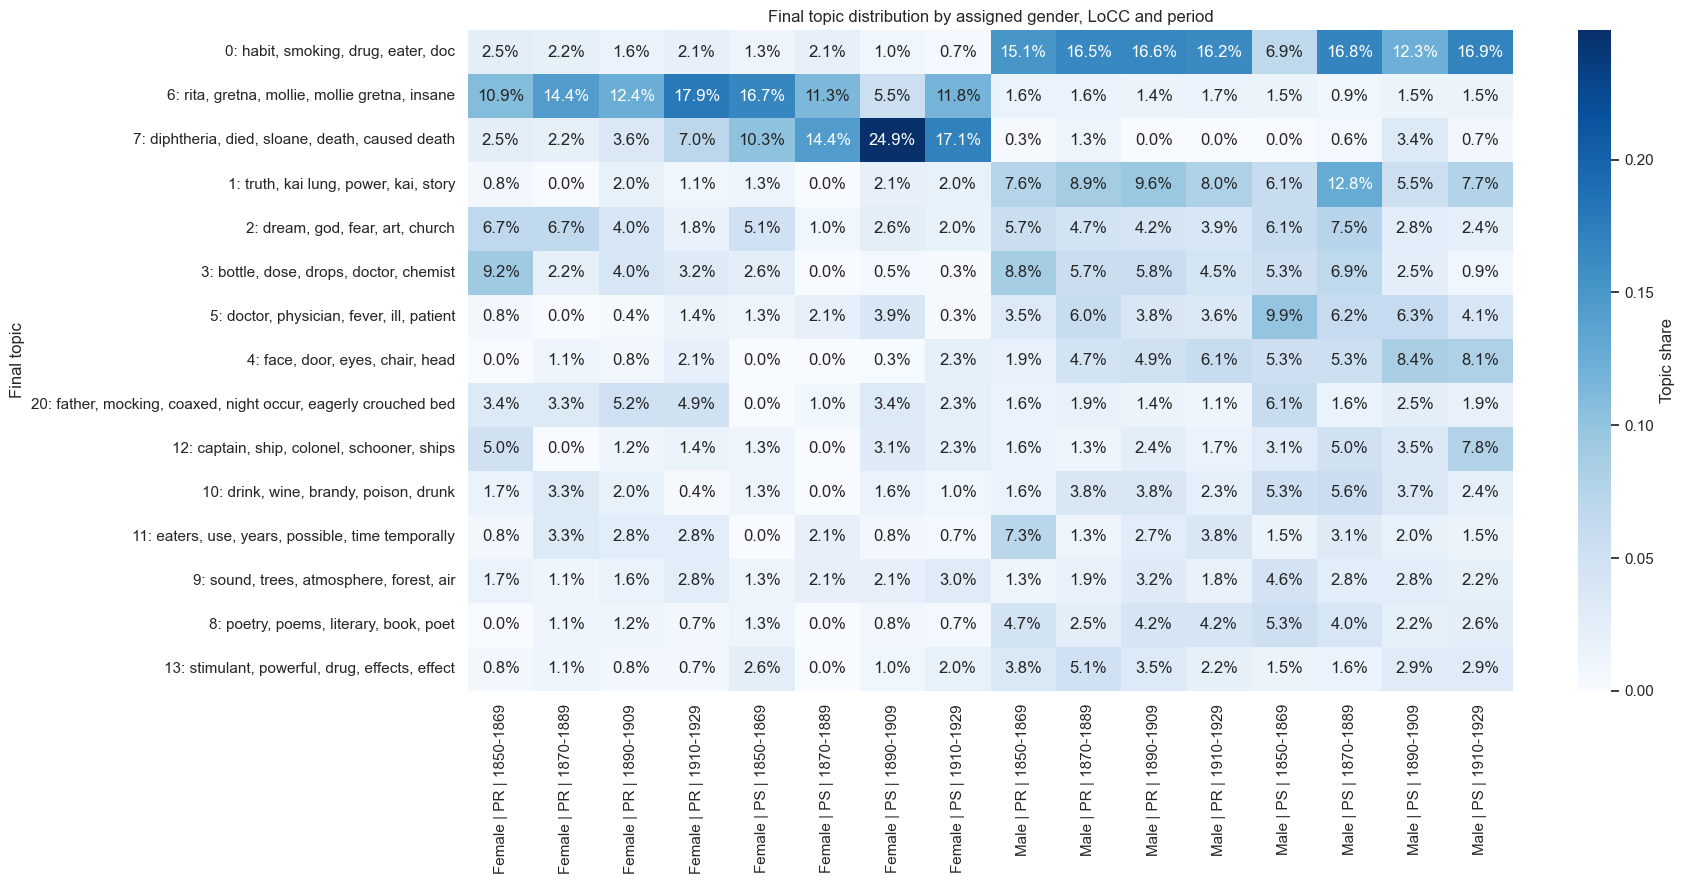

In [141]:
plot_topic_distribution_heatmap(
    combo_assigned_topic_distribution.loc[
        combo_assigned_topic_distribution["LoCC_Display"].isin(["PR", "PS"])
        & combo_assigned_topic_distribution["Assigned_Gender_Group"].isin(["Male", "Female"])
    ],
    ["Assigned_Gender_Group", "LoCC_Display", "Period"],
    "Final topic distribution by assigned gender, LoCC and period",
    top_n_topics=15,
    min_group_total=30,
    figsize=(18, 9),
)

In [142]:
if EXPORT_RESULTS:
    combo_author_counts.to_csv(OUTPUT_DIR / "final_topic_author_gender_locc_period_counts.csv", index=False)
    combo_assigned_counts.to_csv(OUTPUT_DIR / "final_topic_assigned_gender_locc_period_counts.csv", index=False)
    combo_author_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_author_gender_locc_period.csv", index=False)
    combo_assigned_topic_distribution.to_csv(OUTPUT_DIR / "final_topics_by_assigned_gender_locc_period.csv", index=False)